In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [15]:
#define state
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [16]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['bmi']=round(bmi,2)

    return state

In [17]:
def label_BMI(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['category'] = 'Normal weight'
    elif 25 <= bmi < 30:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obesity'

    return state

In [18]:
#define Graph

graph = StateGraph(BMIState)

#add nodes to graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_BMI', label_BMI)

#add edge
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_BMI')
graph.add_edge('label_BMI', END)

#compile graph
workflow = graph.compile()

In [20]:
#execute the graph
initial_state = {'height_m':1.73, 'weight_kg':80}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


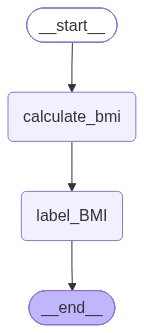

In [19]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())